In [ ]:
import zipfile
import os
import unicodedata

import re

import spacy
nlp = spacy.load("en_core_web_sm")

import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords

from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
zip_path = "/content/Corpus.zip"
extract_path = "data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_path)

print("Unzipped to: ", extract_path)

Unzipped to:  data


In [ ]:
def load_texts(folder_path):
  texts = []
  filenames = []

  for file in os.listdir(folder_path):
    if file.endswith(".txt"):
      path = os.path.join(folder_path, file)
      with open(path, "r", encoding = "utf-8") as f:
        texts.append(f.read())
        filenames.append(file)

  return texts, filenames

In [ ]:
# Step 1: Load the texts (already manually cleaned)
print("Loading texts...")

romantic_texts, romantic_filenames = load_texts("data/english_romantic")
gothic_texts, gothic_filenames = load_texts("data/english_gothic")

print("\nNumber of English Romantic texts: ", len(romantic_texts))
print("Number of English Gothic texts: ", len(gothic_texts))

Loading texts...

Number of English Romantic texts:  6
Number of English Gothic texts:  6


In [ ]:
def preprocess(text):
  """
  Preprocessing that preserves stylistic signals.
  """

  # Archaic characters
  text = re.sub(r'ſ', 's', text)
  text = re.sub(r'æ', 'ae', text)
  text = re.sub(r'œ', 'oe', text)
  text = re.sub(r'ﬁ', 'fi', text)
  text = re.sub(r'ﬂ', 'fl', text)

  # Unicode diacritics
  text = "".join(c for c in unicodedata.normalize("NFD", text) if unicodedata.category(c) != "Mn")

  # Keep only letters and some punctuation ("'.!?:;)
  text = re.sub(r"[^a-zA-Z0-9.,!?;:()\"'\-\s]", "", text)

  # Normalize whitespace
  text = re.sub(r"\s+", " ", text).strip()

  return text

def save_cleaned_texts(texts, filenames, output_folder):
  os.makedirs(output_folder, exist_ok = True)

  for text, filename in zip(texts, filenames):
    out_path = os.path.join(output_folder, filename)
    with open(out_path, "w", encoding = "utf-8") as f:
      f.write(text)

In [ ]:
# Step 2: Preprocess the texts
print("Preprocessing texts...")

romantic_texts = [preprocess(t) for t in romantic_texts]
gothic_texts = [preprocess(t) for t in gothic_texts]

save_cleaned_texts(romantic_texts, romantic_filenames, "./cleaned_romantic")
save_cleaned_texts(gothic_texts, gothic_filenames, "./cleaned_gothic")

print("\n Successfully cleaned and saved files! ")

Preprocessing texts...

 Successfully cleaned and saved files! 


In [ ]:
stop_words = set(stopwords.words("english"))
extra_stopwords = {
  "thy", "thou", "thee", "hath", "doth", "unto",
  "shall", "yet", "would", "could", "one", "upon"
}
stop_words = stop_words.union(extra_stopwords)

def remove_stopwords(text):
  words = text.split()
  return " ".join([word for word in words if word not in stop_words])

def remove_proper_nouns(text, chunk_size = 50000):
  cleaned_chunks = []

  for i in range(0, len(text), chunk_size):
    chunk = text[i:i + chunk_size]
    doc = nlp(chunk)

    cleaned_chunk = " ".join([token.text for token in doc if not (token.pos_ == "PROPN" or token.text.istitle())])
    cleaned_chunks.append(cleaned_chunk)

  return " ".join(cleaned_chunks)

In [ ]:
# Step 3: Further process the texts for keyword counting
print("Further processing...")

print("\nRemoving stopwords...")
romantic_texts = [remove_stopwords(t) for t in romantic_texts]
gothic_texts = [remove_stopwords(t) for t in gothic_texts]
print("\tStopwords removed!")

Further processing...

Removing stopwords...
	Stopwords removed!


In [ ]:
print("\nRemoving proper nouns...")
romantic_texts = [remove_proper_nouns(t) for t in romantic_texts]
gothic_texts = [remove_proper_nouns(t) for t in gothic_texts]
print("\tProper nouns removed!")


Removing proper nouns...
	Proper nouns removed!


In [ ]:
def get_word_counts(texts):
  counter = Counter()
  for text in texts:
    words = text.lower().split()
    counter.update(words)

  return counter

def compute_log_odds(counts_a, counts_b, alpha = 1):
  vocab = set(counts_a.keys()).union(set(counts_b.keys()))

  total_a = sum(counts_a.values())
  total_b = sum(counts_b.values())

  scores = {}

  for word in vocab:
    count_a = counts_a.get(word, 0) + alpha
    count_b = counts_b.get(word, 0) + alpha

    prob_a = count_a / (total_a + alpha * len(vocab))
    prob_b = count_b / (total_b + alpha * len(vocab))

    scores[word] = np.log(prob_a / prob_b)

  return scores

def get_top_k_words(log_odds, k = 20, genre = "romantic"):
  if genre == "romantic":
    return sorted(log_odds.items(), key = lambda x: x[1], reverse = True)[:k]
  else:
    return sorted(log_odds.items(), key = lambda x: x[1])[:k]

In [ ]:
# Step 4: Find the top 'k' words per genre
romantic_counts = get_word_counts(romantic_texts)
gothic_counts = get_word_counts(gothic_texts)

log_odds = compute_log_odds(romantic_counts, gothic_counts)

k = int(input("Enter 'k': "))

top_romantic = get_top_k_words(log_odds, k, "romantic")
top_gothic = get_top_k_words(log_odds, k, "gothic")

print("\nTop Romantic (log-odds):")
print(top_romantic)

print("\nTop Gothic (log-odds):")
print(top_gothic)

Enter 'k': 20

Top Romantic (log-odds):
[('scout', np.float64(5.833234925496946)), ('countess', np.float64(4.87826533905768)), ('rifle', np.float64(4.613786163685563)), ('park', np.float64(4.507405760126991)), ('palatine', np.float64(4.316887436128858)), ('baronet', np.float64(4.266243703310103)), ('m', np.float64(4.25317162174275)), ('trail', np.float64(4.065573007847951)), ('camp', np.float64(4.03331214562973)), ('ladyships', np.float64(4.03331214562973)), ('ladyship', np.float64(4.027832679865105)), ('warrior', np.float64(3.965489549290969)), ('warriors', np.float64(3.920638983125617)), ('royal', np.float64(3.8927301950085407)), ('color', np.float64(3.79363929236431)), ('prince', np.float64(3.70662791537468)), ('tournament', np.float64(3.6360103481607267)), ('center', np.float64(3.560024441182805)), ('yeomen', np.float64(3.560024441182805)), ('encampment', np.float64(3.5333561941006435))]

Top Gothic (log-odds):
[('chateau', np.float64(-4.804949537255921)), ('surprize', np.float64(-

In [ ]:
def plot_log_odds(top_words, title):
  words = [w for w, _ in top_words]
  scores = [s for _, s in top_words]

  plt.figure(figsize = (10, 6))
  sns.barplot(x = scores, y = words)

  plt.title(title)
  plt.xlabel("Log-Odds Score")
  plt.ylabel("Words")
  plt.axvline(0, color = 'black', linestyle = '--')

  plt.tight_layout()
  plt.show()

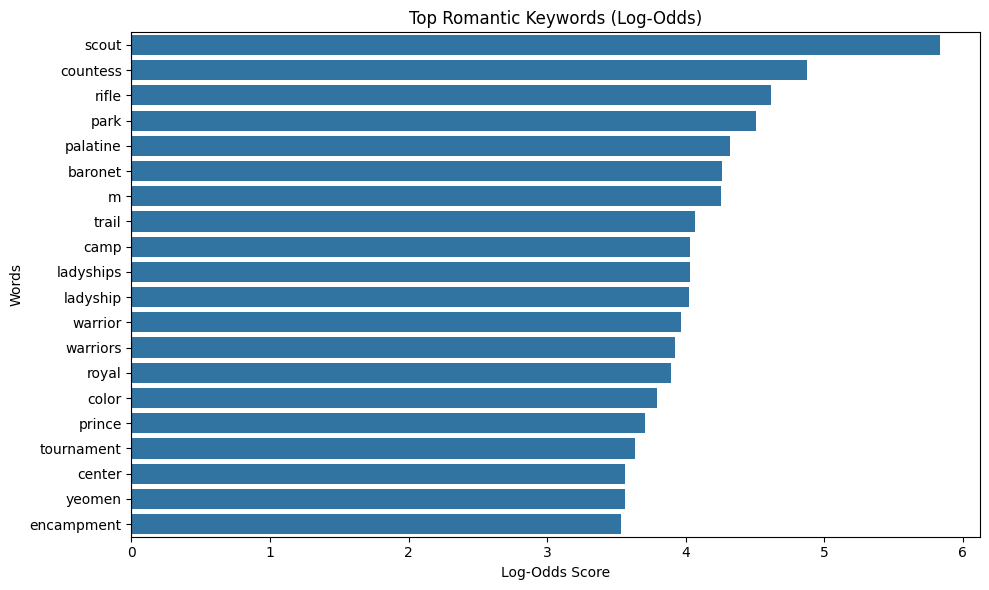

In [ ]:
plot_log_odds(top_romantic, "Top Romantic Keywords (Log-Odds)")

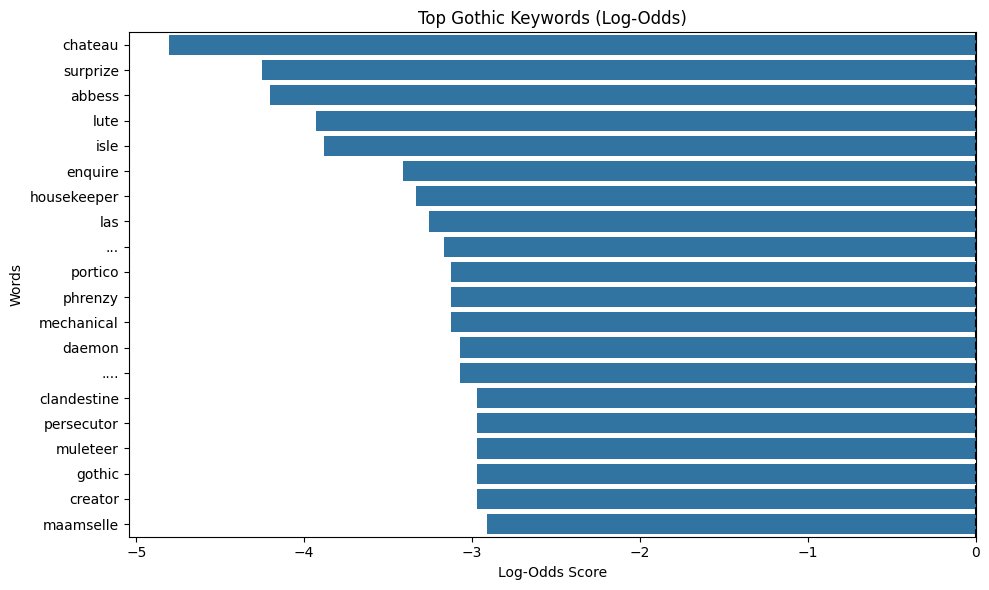

In [ ]:
plot_log_odds(top_gothic, "Top Gothic Keywords (Log-Odds)")